# T1 vs I2 — Telemetry Comparison\n\nSide-by-side comparison of GPU telemetry signals under two conditions:\n- **T1**: DDP pre-training, 3.37B-param GPT, 8×A100, ~5 min\n- **I2**: Streaming autoregressive inference, Llama-3.1-8B, 8×A100, ~5 min\n\nGoal: establish ground-truth signal fingerprints for training vs. inference.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── Load ──────────────────────────────────────────────────────────────────────
t1_raw = pd.read_csv("../data/t1_telemetry.csv")
i2_raw = pd.read_csv("../data/i2_telemetry.csv")

def prep(df, label):
    df = df.copy()
    df["label"] = label
    # Normalize timestamp to seconds since first sample
    df["t"] = df["timestamp"] - df["timestamp"].min()
    return df

t1 = prep(t1_raw, "T1 training")
i2 = prep(i2_raw, "I2 inference")

# Steady-state only subsets (used for distributions)
t1_s = t1[t1.phase == "steady"]
i2_s = i2[i2.phase == "steady"]

print(f"T1 steady: {t1_s.t.max():.0f}s × 8 GPUs = {len(t1_s)} rows")
print(f"I2 steady: {i2_s.t.max():.0f}s × 8 GPUs = {len(i2_s)} rows")

T1 steady: 334s × 8 GPUs = 2160 rows
I2 steady: 411s × 8 GPUs = 2944 rows


## 1. Time Series — All Signals\n\nMean across 8 GPUs per second. Shaded region = ±1 std across GPUs (shows inter-GPU spread). Vertical dashed lines mark phase boundaries.

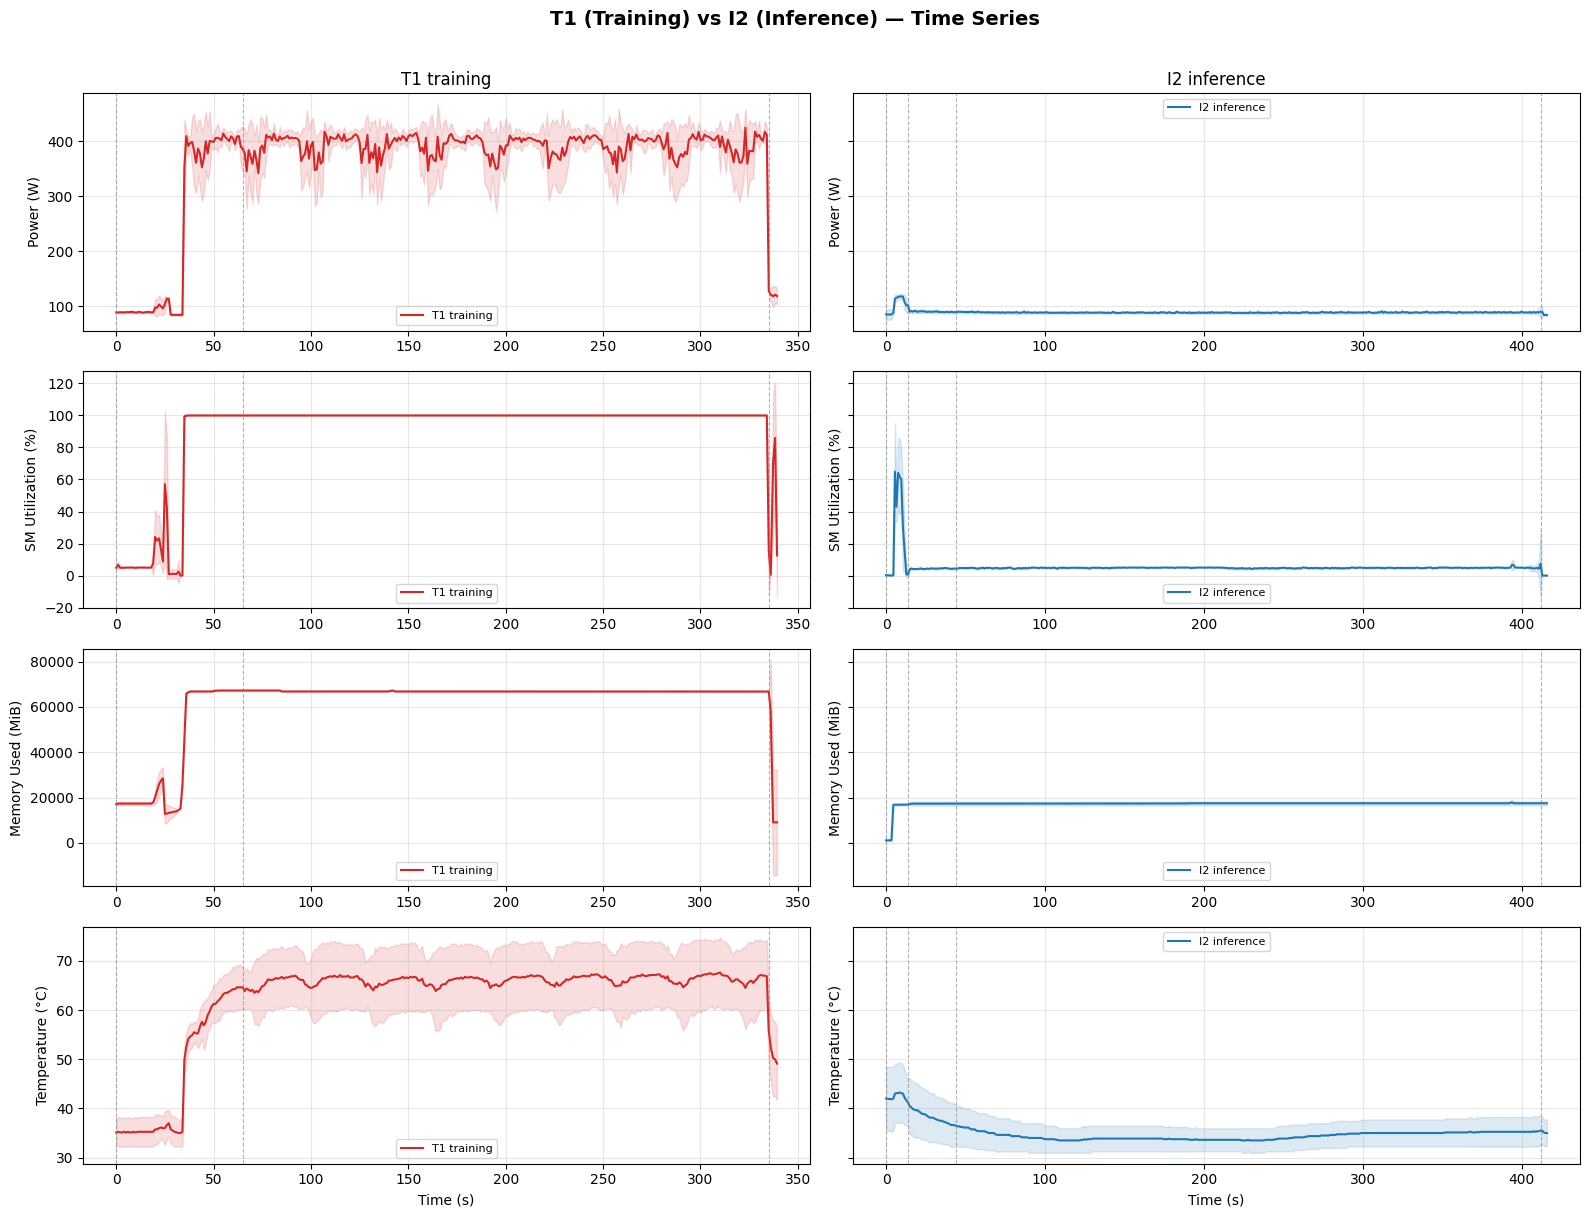

Saved → comparison_timeseries.png


In [2]:
SIGNALS = [
    ("power_w",      "Power (W)",          "tab:red"),
    ("sm_util_pct",  "SM Utilization (%)", "tab:blue"),
    ("mem_used_mib", "Memory Used (MiB)",  "tab:green"),
    ("temp_c",       "Temperature (°C)",   "tab:orange"),
]
COLORS = {"T1 training": "tab:red", "I2 inference": "tab:blue"}

def phase_boundaries(df):
    """Return dict of phase -> first timestamp (normalized)."""
    return df.groupby("phase")["t"].min().to_dict()

def plot_timeseries(ax, df, col, color, label):
    agg = df.groupby("t")[col].agg(["mean", "std"]).reset_index()
    ax.plot(agg["t"], agg["mean"], color=color, lw=1.5, label=label)
    ax.fill_between(agg["t"],
                    agg["mean"] - agg["std"],
                    agg["mean"] + agg["std"],
                    color=color, alpha=0.15)
    # Phase boundaries
    for phase, t in phase_boundaries(df).items():
        ax.axvline(t, color="gray", lw=0.8, ls="--", alpha=0.6)

fig, axes = plt.subplots(len(SIGNALS), 2, figsize=(16, 12), sharey="row")
fig.suptitle("T1 (Training) vs I2 (Inference) — Time Series", fontsize=14, fontweight="bold", y=1.01)

for row, (col, ylabel, _) in enumerate(SIGNALS):
    for col_idx, (df, label, color) in enumerate([
        (t1, "T1 training", "tab:red"),
        (i2, "I2 inference", "tab:blue"),
    ]):
        ax = axes[row, col_idx]
        plot_timeseries(ax, df, col, color, label)
        ax.set_ylabel(ylabel, fontsize=10)
        ax.set_xlabel("Time (s)" if row == len(SIGNALS) - 1 else "")
        ax.set_title(label if row == 0 else "")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../comparison_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → comparison_timeseries.png")

## 2. Distribution Comparison (Steady State)\n\nViolin plots across all 8 GPUs × steady-state seconds. Shows not just mean but the full shape of each signal's distribution — important for understanding how separable the two conditions are.

/tmp/ipykernel_31440/40745951.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=combined, x="label", y=col, palette=palette,
/tmp/ipykernel_31440/40745951.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=combined, x="label", y=col, palette=palette,
/tmp/ipykernel_31440/40745951.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=combined, x="label", y=col, palette=palette,
/tmp/ipykernel_31440/40745951.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. A

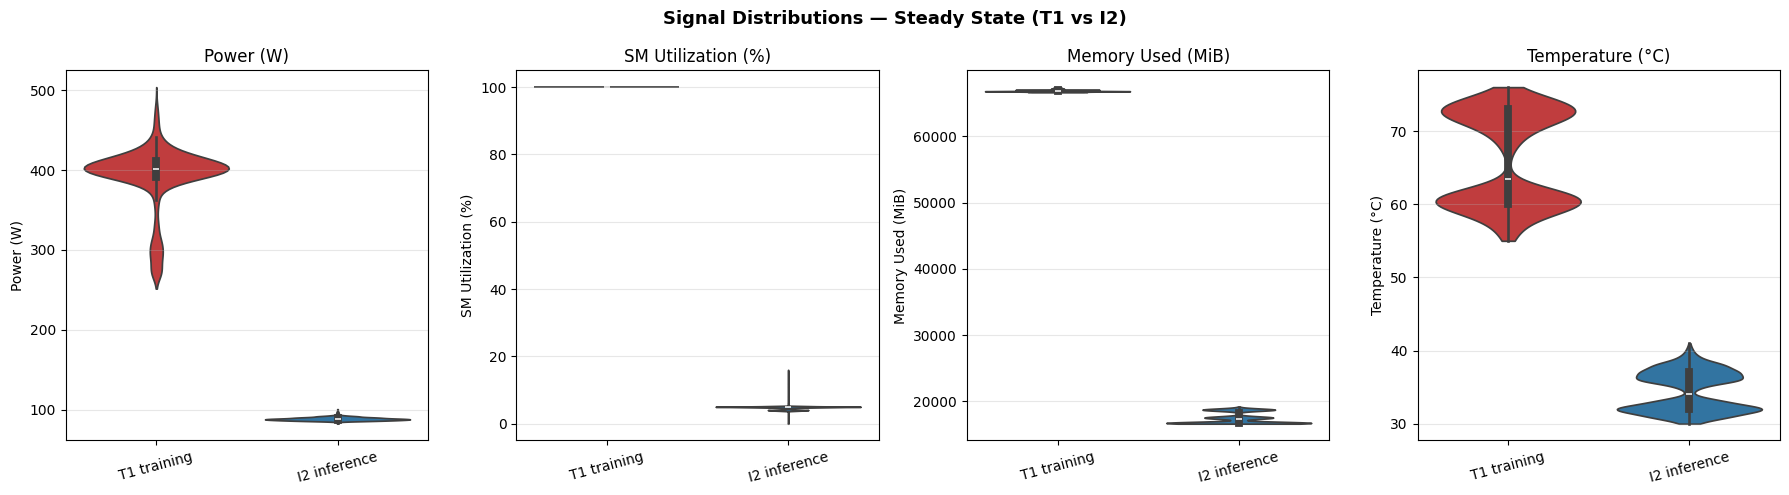

Saved → comparison_distributions.png


In [3]:
combined = pd.concat([t1_s, i2_s], ignore_index=True)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle("Signal Distributions — Steady State (T1 vs I2)", fontsize=13, fontweight="bold")

palette = {"T1 training": "tab:red", "I2 inference": "tab:blue"}

for ax, (col, ylabel, _) in zip(axes, SIGNALS):
    sns.violinplot(data=combined, x="label", y=col, palette=palette,
                   inner="box", cut=0, ax=ax)
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.tick_params(axis="x", rotation=15)
    ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("../comparison_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → comparison_distributions.png")

## 3. GPU × Time Heatmaps\n\nEach cell = one GPU's value at one second. Shows inter-GPU symmetry (or lack of it) — training should be highly symmetric across GPUs due to DDP; inference less so.

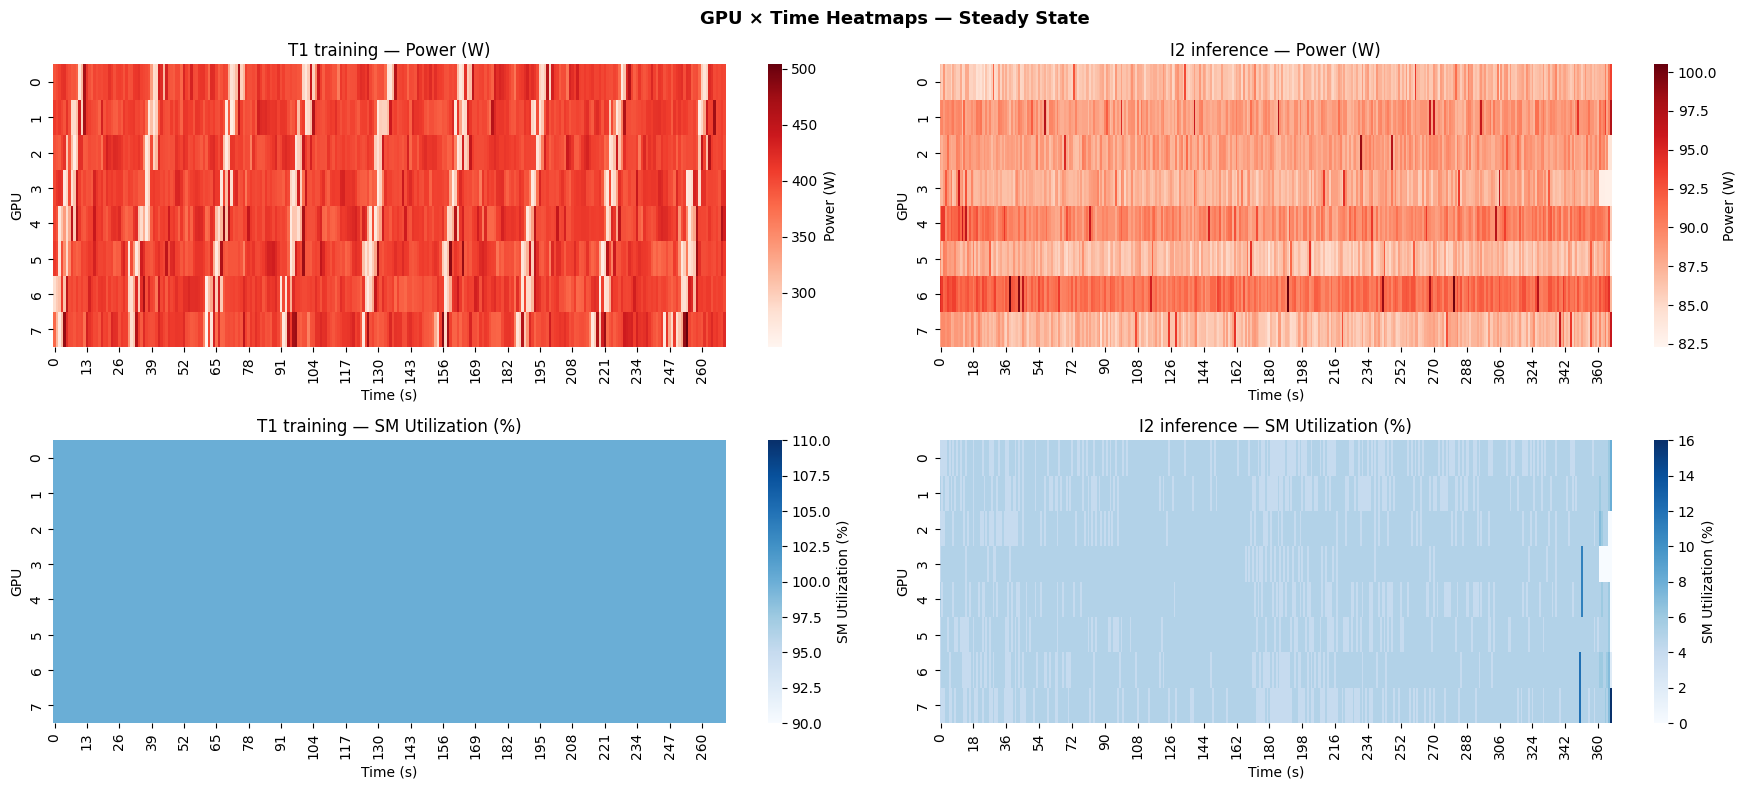

Saved → comparison_heatmaps.png


In [4]:
def make_heatmap_matrix(df, col):
    """Pivot to GPU × time matrix using steady-state data, t rounded to int."""
    s = df[df.phase == "steady"].copy()
    s["t_int"] = (s["t"] - s["t"].min()).round().astype(int)
    return s.pivot_table(index="gpu", columns="t_int", values=col, aggfunc="mean")

heatmap_signals = [
    ("power_w",     "Power (W)",          "Reds"),
    ("sm_util_pct", "SM Utilization (%)", "Blues"),
]

fig, axes = plt.subplots(2, 2, figsize=(18, 8))
fig.suptitle("GPU × Time Heatmaps — Steady State", fontsize=13, fontweight="bold")

for row, (col, title, cmap) in enumerate(heatmap_signals):
    for col_idx, (df, label) in enumerate([(t1, "T1 training"), (i2, "I2 inference")]):
        ax = axes[row, col_idx]
        mat = make_heatmap_matrix(df, col)
        sns.heatmap(mat, ax=ax, cmap=cmap, cbar=True,
                    cbar_kws={"label": title},
                    xticklabels=max(1, mat.shape[1] // 20),
                    yticklabels=True)
        ax.set_title(f"{label} — {title}")
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("GPU")

plt.tight_layout()
plt.savefig("../comparison_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → comparison_heatmaps.png")

## 4. Power Temporal Variability\n\nStd deviation of power across GPUs at each second. Training should show periodic spikes (allreduce sync moments causing brief power drops across all GPUs simultaneously). Inference should be flatter.

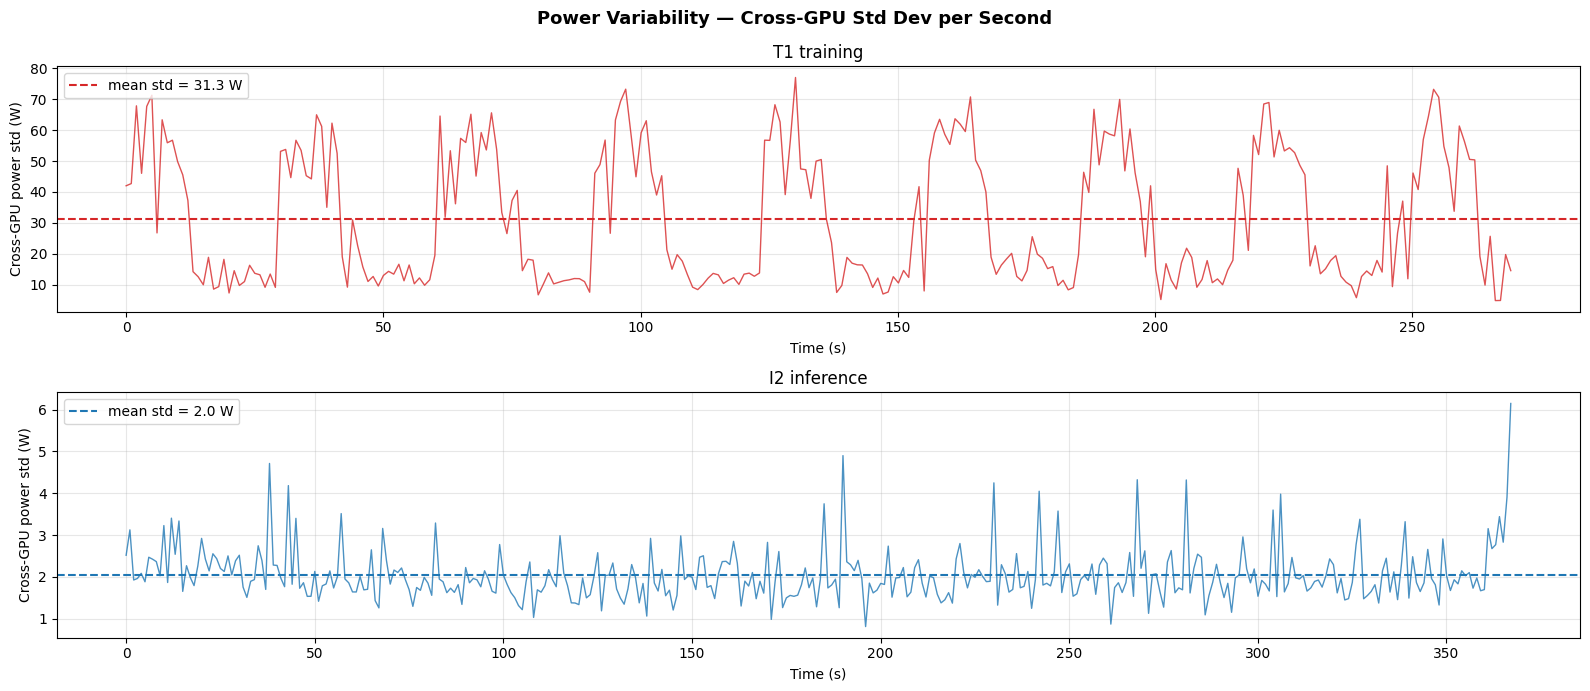

Saved → comparison_power_variability.png


In [5]:
fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=False)
fig.suptitle("Power Variability — Cross-GPU Std Dev per Second", fontsize=13, fontweight="bold")

for ax, (df, label, color) in zip(axes, [
    (t1, "T1 training", "tab:red"),
    (i2, "I2 inference", "tab:blue"),
]):
    s = df[df.phase == "steady"].copy()
    per_sec = s.groupby("t")["power_w"].agg(["mean", "std"]).reset_index()
    ax.plot(per_sec["t"] - per_sec["t"].min(), per_sec["std"],
            color=color, lw=1, alpha=0.8)
    ax.axhline(per_sec["std"].mean(), color=color, lw=1.5, ls="--",
               label=f"mean std = {per_sec['std'].mean():.1f} W")
    ax.set_ylabel("Cross-GPU power std (W)")
    ax.set_xlabel("Time (s)")
    ax.set_title(label)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../comparison_power_variability.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → comparison_power_variability.png")

## 5. Summary Statistics Table

In [6]:
cols = ["power_w", "sm_util_pct", "mem_used_mib", "temp_c", "clock_sm_mhz"]
col_labels = ["Power (W)", "SM Util (%)", "Memory (MiB)", "Temp (°C)", "SM Clock (MHz)"]

rows = []
for col, label in zip(cols, col_labels):
    t1_vals = t1_s[col]
    i2_vals = i2_s[col]
    rows.append({
        "Signal":    label,
        "T1 mean":   f"{t1_vals.mean():.1f}",
        "T1 std":    f"{t1_vals.std():.1f}",
        "I2 mean":   f"{i2_vals.mean():.1f}",
        "I2 std":    f"{i2_vals.std():.1f}",
        "T1/I2 ratio": f"{t1_vals.mean() / i2_vals.mean():.2f}×",
    })

summary = pd.DataFrame(rows).set_index("Signal")
summary

,T1 mean,T1 std,I2 mean,I2 std,T1/I2 ratio
Signal,,,,,
Power (W),392.4,39.6,88.4,2.1,4.44×
SM Util (%),100.0,0.0,4.8,0.6,20.94×
Memory (MiB),66857.7,163.9,17450.7,824.2,3.83×
Temp (°C),66.1,6.4,34.4,2.7,1.92×
SM Clock (MHz),1301.2,40.6,1155.0,0.0,1.13×
